<a href="https://colab.research.google.com/github/jane-disciullo/sp500-backtesting-strategy/blob/main/notebooks/01_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Overview
This project backtests a simple systematic trading strategy on the S&P 500 using historical SPY data. The strategy is based on a 200-day moving average, which is used to decide when to stay invested in the market or move to cash.
We compare the performance of this strategy against a basic buy and hold approach using $SPY. The main goal is to see whether this rule-based method can deliver similar or better returns while reducing risk.
To evaluate the strategy, we look at key performance and risk metrics such as total return, CAGR, Sharpe ratio, and maximum drawdown.

This notebook was developed with the assistance of artificial intelligence (AI) tools, which were utilized for code debugging, troubleshooting error messages, and correcting syntax.

# Part 2 & 3: Importing Data and Libraries, Downloading $SPY Data
``` I am using $SPY because the S&P isn’t an actual index (cannot be directly traded), EFTs ($SPY) historical price data is easier to work with```

In [58]:
## Part 2 & 3
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from src.data import load_spy_data

starting_balance = 100_000
ma = 200

start = datetime(2015, 1, 1)
end = datetime(2026, 1, 1)
ticker = 'SPY'
interval = '1d'

price = load_spy_data(
    start=start,
    end=end,
)

/content/sp500-backtesting-strategy/src/data.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(
[*********************100%***********************]  1 of 1 completed


# Part 4: Data Exploration

In [59]:
## Dataset Overview
price.head(10)
price.tail(10)
price.shape
price.info()
price.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2766 non-null   float64
 1   High    2766 non-null   float64
 2   Low     2766 non-null   float64
 3   Open    2766 non-null   float64
 4   Volume  2766 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.7 KB


,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [60]:
## Data Quality
price.index.duplicated().sum()
price.dtypes
price.duplicated().sum()
price.describe()
(price[['Open', 'High', 'Low', 'Close']] <= 0).sum()

,0
Open,0
High,0
Low,0
Close,0


In [61]:
## Dataset Time Period
first_timestamp = price.index.min()
last_timestamp = price.index.max()


years = (last_timestamp - first_timestamp).days / 365.25

years

10.99520876112252

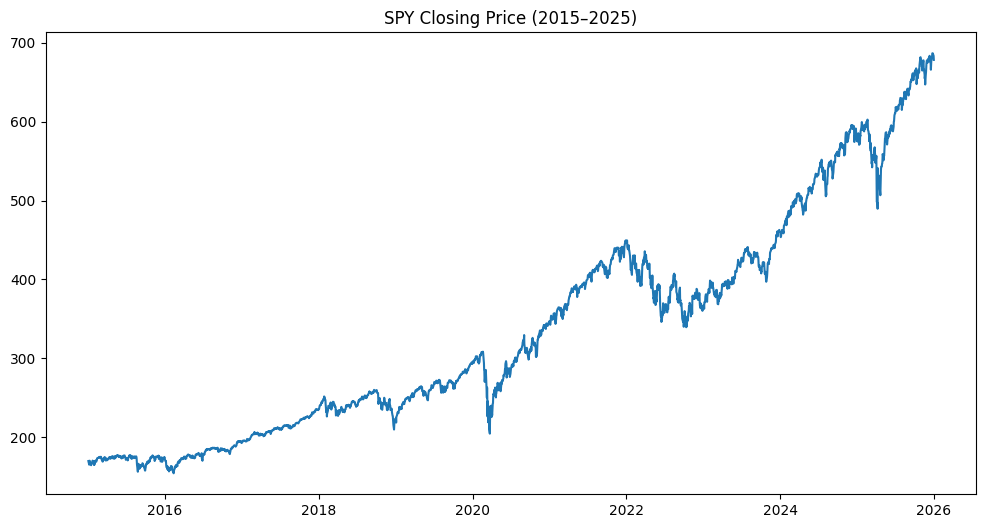

In [62]:
## Visuals For Price
plt.figure(figsize = (12, 6))
plt.title('SPY Closing Price (2015–2025)')
plt.plot(price['Close'])
plt.show()

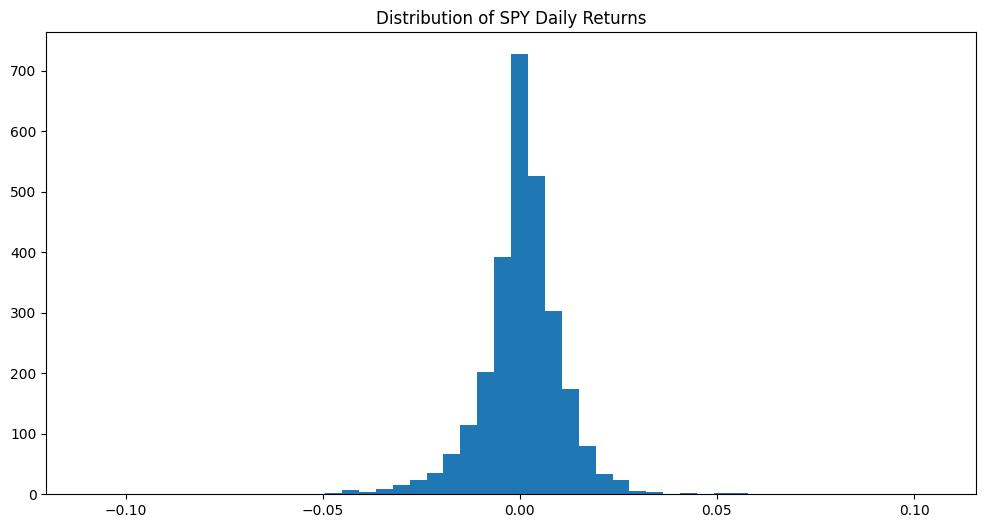

In [63]:
## Daily Percentage Returns
price['Daily_Return'] = price['Close'].pct_change()
plt.figure(figsize=(12, 6))

plt.hist(price['Daily_Return'].dropna(), bins=50)

plt.title('Distribution of SPY Daily Returns')

plt.show()

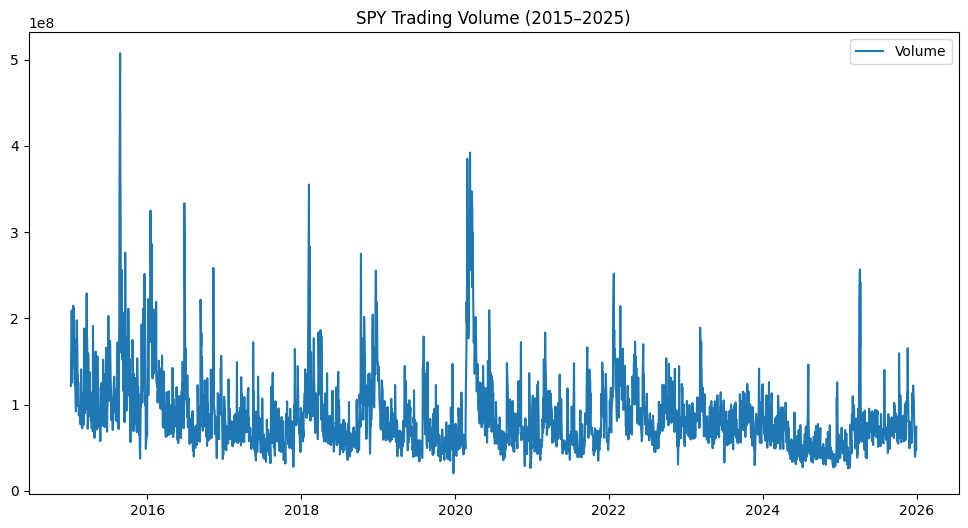

In [64]:
## Trading Volume
plt.figure(figsize=(12, 6))

plt.plot(price.index, price['Volume'], label='Volume')

plt.title('SPY Trading Volume (2015–2025)')
plt.legend()
plt.show()

# Part 5: Define Strategy

In [65]:
from src.signals import generate_ma_signal

price = generate_ma_signal(
    price,
    ma=ma
)

price

,Close,High,Low,Open,Volume,Daily_Return,MA,Long
Date,,,,,,,,
2015-01-02,169.687805,170.885534,168.655289,170.472527,121465900,NaN,NaN,False
2015-01-05,166.623367,168.812297,166.317746,168.647097,169632600,-0.018059,NaN,False
2015-01-06,165.053925,167.449357,164.260947,166.928965,209151400,-0.009419,NaN,False
2015-01-07,167.110687,167.449356,165.929495,166.375536,125346700,0.012461,NaN,False
2015-01-08,170.076096,170.290867,168.498420,168.514931,147217800,0.017745,NaN,False
...,...,...,...,...,...,...,...,...
2025-12-24,686.730530,687.178163,684.164151,684.313382,39445600,0.003518,617.572878,True
2025-12-26,686.660889,688.003728,685.626408,686.989161,41613300,-0.000101,618.258867,True
2025-12-29,684.213867,685.556767,682.443308,683.905508,62559500,-0.003564,618.969243,True


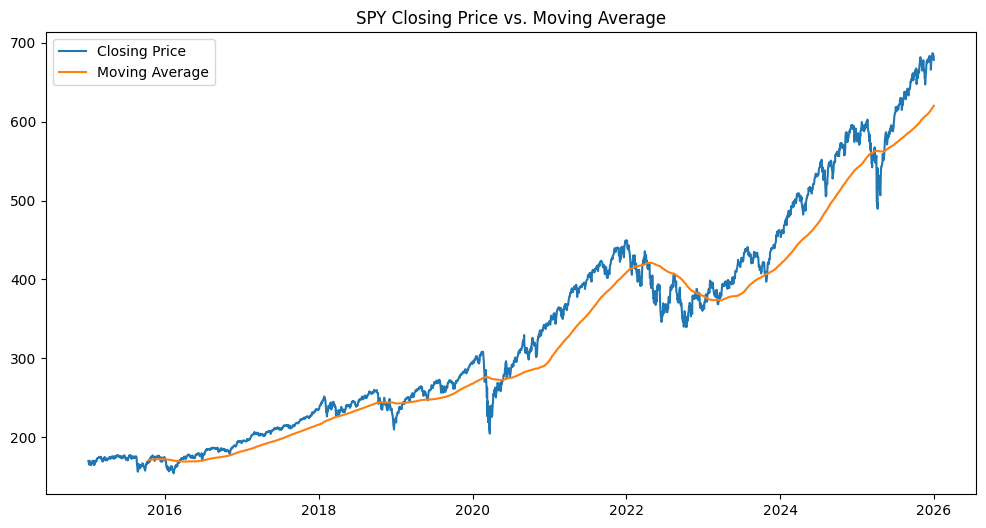

In [66]:
## Moving Average Chart
plt.figure(figsize=(12, 6))
plt.title('SPY Closing Price vs. Moving Average')
plt.plot(price.Close, label='Closing Price')
plt.plot(price.MA, label='Moving Average')
plt.legend()

# Part 6: Calculate Returns

In [67]:
## Daily Returns
price['Return'] = price.Close / price.Close.shift(1)
price.loc[price.index[0], 'Return'] = 1
price[['Close', 'Return']].head()
price

,Close,High,Low,Open,Volume,Daily_Return,MA,Long,Return
Date,,,,,,,,,
2015-01-02,169.687805,170.885534,168.655289,170.472527,121465900,NaN,NaN,False,1.000000
2015-01-05,166.623367,168.812297,166.317746,168.647097,169632600,-0.018059,NaN,False,0.981941
2015-01-06,165.053925,167.449357,164.260947,166.928965,209151400,-0.009419,NaN,False,0.990581
2015-01-07,167.110687,167.449356,165.929495,166.375536,125346700,0.012461,NaN,False,1.012461
2015-01-08,170.076096,170.290867,168.498420,168.514931,147217800,0.017745,NaN,False,1.017745
...,...,...,...,...,...,...,...,...,...
2025-12-24,686.730530,687.178163,684.164151,684.313382,39445600,0.003518,617.572878,True,1.003518
2025-12-26,686.660889,688.003728,685.626408,686.989161,41613300,-0.000101,618.258867,True,0.999899
2025-12-29,684.213867,685.556767,682.443308,683.905508,62559500,-0.003564,618.969243,True,0.996436


# Part 7: Build, Buy, & Hold Benchmark

In [68]:
price['Bench_Bal'] = starting_balance * price['Return'].cumprod()
price

price

,Close,High,Low,Open,Volume,Daily_Return,MA,Long,Return,Bench_Bal
Date,,,,,,,,,,
2015-01-02,169.687805,170.885534,168.655289,170.472527,121465900,NaN,NaN,False,1.000000,100000.000000
2015-01-05,166.623367,168.812297,166.317746,168.647097,169632600,-0.018059,NaN,False,0.981941,98194.073014
2015-01-06,165.053925,167.449357,164.260947,166.928965,209151400,-0.009419,NaN,False,0.990581,97269.172873
2015-01-07,167.110687,167.449356,165.929495,166.375536,125346700,0.012461,NaN,False,1.012461,98481.259206
2015-01-08,170.076096,170.290867,168.498420,168.514931,147217800,0.017745,NaN,False,1.017745,100228.826347
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,686.730530,687.178163,684.164151,684.313382,39445600,0.003518,617.572878,True,1.003518,404702.346803
2025-12-26,686.660889,688.003728,685.626408,686.989161,41613300,-0.000101,618.258867,True,0.999899,404661.306074
2025-12-29,684.213867,685.556767,682.443308,683.905508,62559500,-0.003564,618.969243,True,0.996436,403219.233391


# Part 8: Strategy Portfolio

In [69]:
## Return
from src.backtest import run_backtest

price = run_backtest(
    price,
    starting_balance=starting_balance
)

price

,Close,High,Low,Open,Volume,Daily_Return,MA,Long,Return,Bench_Bal,Sys_Ret,Sys_Bal
Date,,,,,,,,,,,,
2015-01-02,169.687805,170.885534,168.655289,170.472527,121465900,NaN,NaN,False,1.000000,100000.000000,1.000000,100000.000000
2015-01-05,166.623367,168.812297,166.317746,168.647097,169632600,-0.018059,NaN,False,0.981941,98194.073014,1.000000,100000.000000
2015-01-06,165.053925,167.449357,164.260947,166.928965,209151400,-0.009419,NaN,False,0.990581,97269.172873,1.000000,100000.000000
2015-01-07,167.110687,167.449356,165.929495,166.375536,125346700,0.012461,NaN,False,1.012461,98481.259206,1.000000,100000.000000
2015-01-08,170.076096,170.290867,168.498420,168.514931,147217800,0.017745,NaN,False,1.017745,100228.826347,1.000000,100000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,686.730530,687.178163,684.164151,684.313382,39445600,0.003518,617.572878,True,1.003518,404702.346803,1.003518,292259.294648
2025-12-26,686.660889,688.003728,685.626408,686.989161,41613300,-0.000101,618.258867,True,0.999899,404661.306074,0.999899,292229.656731
2025-12-29,684.213867,685.556767,682.443308,683.905508,62559500,-0.003564,618.969243,True,0.996436,403219.233391,0.996436,291188.251489


# Part 9: Performance Metrics

In [70]:
from src.metrics import calculate_total_return

total_returns = calculate_total_return(
    price,
    starting_balance=starting_balance
)

final_bench = total_returns["final_bench"]
final_strategy = total_returns["final_strategy"]
bench_total_return = total_returns["bench_total_return"]
sys_total_return = total_returns["sys_total_return"]

print(f"Buy and Hold Final Value: ${final_bench:,.2f}")
print(f"Strategy Final Value: ${final_strategy:,.2f}")

print(f"Buy and Hold Total Return: {bench_total_return:.2%}")
print(f"Strategy Total Return: {sys_total_return:.2%}")

Buy and Hold Final Value: $399,743.07
Strategy Final Value: $288,677.91
Buy and Hold Total Return: 299.74%
Strategy Total Return: 188.68%


In [71]:
from src.metrics import calculate_sharpe_ratio

sharpe = calculate_sharpe_ratio(price)

bench_sharpe = sharpe["bench_sharpe"]
strategy_sharpe = sharpe["strategy_sharpe"]

print(f"$SPY Sharpe Ratio: {bench_sharpe:.2f}")
print(f"Strategy Sharpe Ratio: {strategy_sharpe:.2f}")

$SPY Sharpe Ratio: 0.80
Strategy Sharpe Ratio: 0.90


In [72]:
from src.metrics import calculate_cagr

cagr = calculate_cagr(
    price,
    years=years
)

cagr_bench = cagr["cagr_bench"]
cagr_strategy = cagr["cagr_strategy"]

print(f"Benchmark CAGR: {cagr_bench:.2%}")
print(f"Strategy CAGR: {cagr_strategy:.2%}")

Benchmark CAGR: 13.43%
Strategy CAGR: 10.12%


In [73]:
from src.metrics import calculate_max_drawdown

drawdown = calculate_max_drawdown(price)

dd_bench = drawdown["dd_bench"]
dd_strategy = drawdown["dd_strategy"]

print(f"Buy & Hold Max Drawdown: {dd_bench:.2f}%")
print(f"Strategy Max Drawdown: {dd_strategy:.2f}%")

Buy & Hold Max Drawdown: -33.72%
Strategy Max Drawdown: -19.81%


# Part 10: Equity Curve

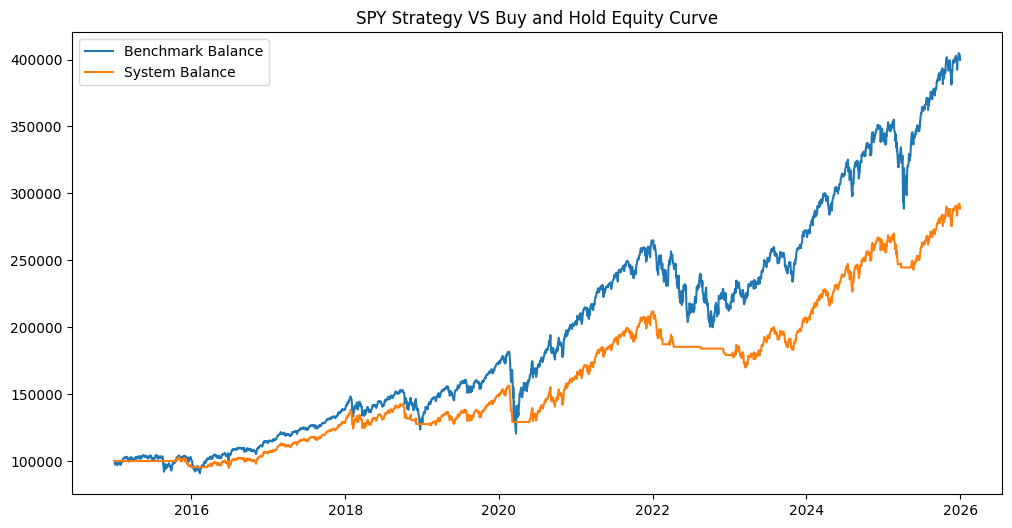

In [74]:
plt.figure(figsize=(12,6))
plt.plot(price.Bench_Bal, label='Benchmark Balance')
plt.plot(price.Sys_Bal, label='System Balance')
plt.title('SPY Strategy VS Buy and Hold Equity Curve')
plt.legend()
plt.show()

# Part 11: Drawdown Analysis

In [75]:
price['Bench_Peak'] = price['Bench_Bal'].cummax()
price['Bench_DD'] = price['Bench_Bal'] - price['Bench_Peak']
price['Sys_Peak'] = price['Sys_Bal'].cummax()
price['Sys_DD'] = price['Sys_Bal'] - price['Sys_Peak']

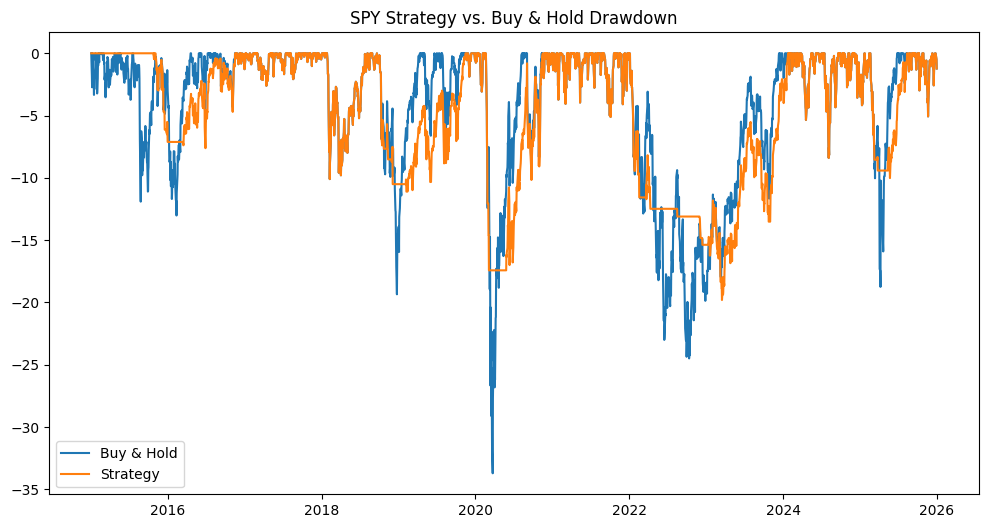

In [76]:
plt.figure(figsize=(12, 6))

plt.plot(price.index,(price['Bench_DD'] / price['Bench_Peak']) * 100,label='Buy & Hold')
plt.plot(price.index,(price['Sys_DD'] / price['Sys_Peak']) * 100, label='Strategy')
plt.title('SPY Strategy vs. Buy & Hold Drawdown')
plt.legend()
plt.show()

# Part 12: Transaction Costs

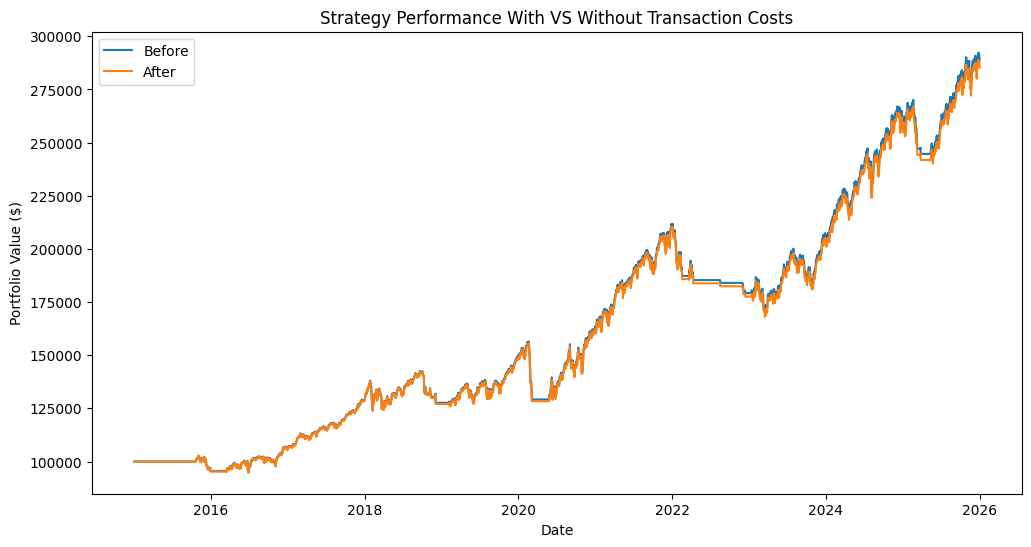

In [77]:
transaction_cost = 0.0002  # as a percent: .02
price['Trade'] = price['Long'].ne(price['Long'].shift(1))
price['Sys_Ret_Cost'] = np.where(price['Trade'], price['Sys_Ret'] * (1 - transaction_cost), price['Sys_Ret'])
price['Sys_Bal_Cost'] = starting_balance * price['Sys_Ret_Cost'].cumprod()
plt.figure(figsize=(12, 6))
plt.plot(price.index, price['Sys_Bal'], label='Before')
plt.plot(price.index, price['Sys_Bal_Cost'], label='After')
plt.title('Strategy Performance With VS Without Transaction Costs')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.show()

# Part 13: Results and Discussion

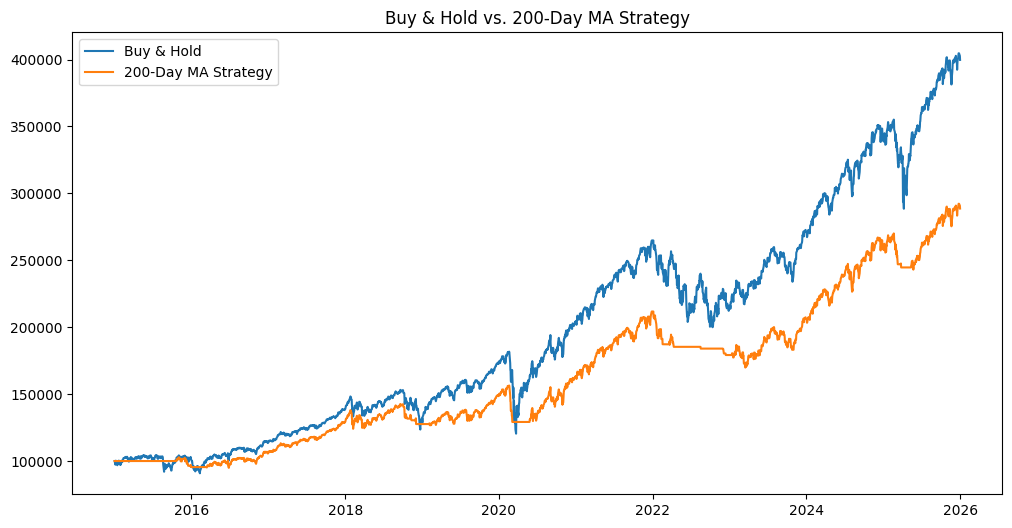

,Buy & Hold,200-Day MA Strategy
Final Value,399743.072803,288677.912102
Total Return,2.997431,1.886779
CAGR,0.134309,0.101220
Sharpe Ratio,0.799137,0.904632
Max Drawdown,-33.717286,-19.806833


In [78]:
plt.figure(figsize=(12, 6))
plt.plot(price.index, price['Bench_Bal'], label='Buy & Hold')
plt.plot(price.index, price['Sys_Bal'], label='200-Day MA Strategy')
plt.title('Buy & Hold vs. 200-Day MA Strategy')
plt.legend()
plt.show()
results = pd.DataFrame({'Buy & Hold': [price['Bench_Bal'].iloc[-1], bench_total_return, cagr_bench, bench_sharpe, dd_bench],'200-Day MA Strategy': [price['Sys_Bal'].iloc[-1], sys_total_return, cagr_strategy, strategy_sharpe, dd_strategy]}, index=['Final Value', 'Total Return', 'CAGR', 'Sharpe Ratio', 'Max Drawdown'])
results

# Part 14: Limitations
Below are a few limitations to this backtest. The strategy only uses a 200-day MA and historical SPY data, so it may not work the same way in different markets. My backtest also doesn't consider taxes, slippage, bid-ask spreads, or delays when executing orders. I included an estimated transaction cost, but actual trading costs can be different. Also, just because the strategy performed a certain way in the past does not mean it will perform the same way in the future. As we know, markets are unpredictable, and this strategy is not certain to perform the same way across different market conditions. The graph I inserted below is an accurate visual on why past performance isn't guaranteed to continue in future markets.

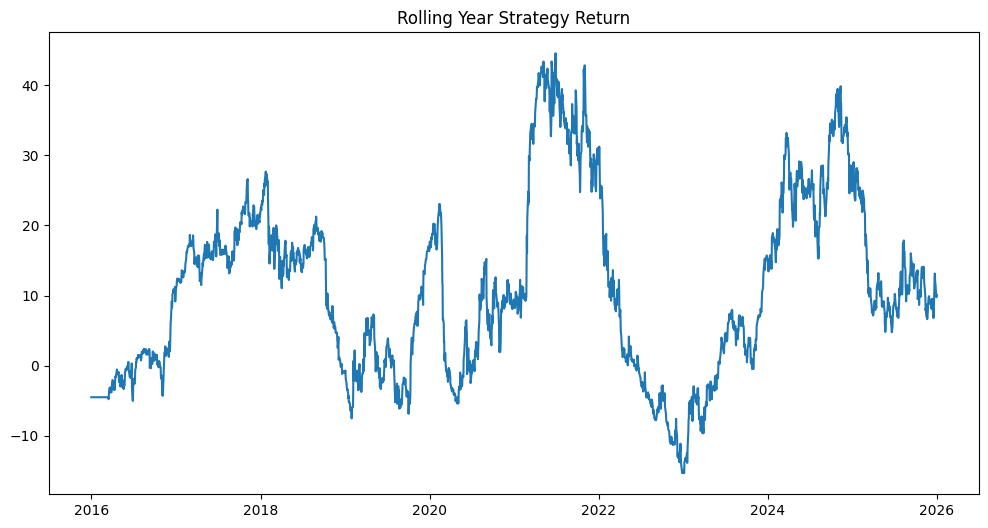

In [79]:
plt.figure(figsize=(12, 6))
rolling_return = price['Sys_Ret'].rolling(252).apply(lambda x: np.prod(x) - 1)
plt.plot(price.index, rolling_return * 100)
plt.title('Rolling Year Strategy Return')
plt.show()